In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import joblib
import warnings
warnings.filterwarnings('ignore')

In [27]:
# ============================================
# 1. INPUT
# ============================================
df = pd.read_csv('cardio_train.csv', delimiter=';')
df = df.drop('id', axis=1)

print("Data berhasil di-load!")
print(f"Jumlah data: {len(df)} baris, {len(df.columns)} kolom")
print("\nKolom yang tersedia:", df.columns.tolist())
print("\n5 data pertama:")
print(df.head())

Data berhasil di-load!
Jumlah data: 70000 baris, 12 kolom

Kolom yang tersedia: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

5 data pertama:
     age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0  18393       2     168    62.0    110     80            1     1      0   
1  20228       1     156    85.0    140     90            3     1      0   
2  18857       1     165    64.0    130     70            3     1      0   
3  17623       2     169    82.0    150    100            1     1      0   
4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  


In [28]:
# ============================================
# 2. PREPROCESSING
# ============================================

# --- 2a. Cleaning ---
# Konversi age dari hari ke tahun
df['age'] = df['age'] / 365.25

# Fungsi hapus outlier
def remove_outliers(df, col, lower=0.01, upper=0.99):
    q_low = df[col].quantile(lower)
    q_high = df[col].quantile(upper)
    return df[(df[col] >= q_low) & (df[col] <= q_high)]

# Hapus outlier
df = remove_outliers(df, 'ap_hi')
df = remove_outliers(df, 'ap_lo')
df = remove_outliers(df, 'height')
df = remove_outliers(df, 'weight')

print("Preprocessing selesai!")
print(f"Jumlah data setelah cleaning: {len(df)} baris")
print("\nStatistik data:")
print(df.describe())

Preprocessing selesai!
Jumlah data setelah cleaning: 66480 baris

Statistik data:
                age        gender        height        weight         ap_hi  \
count  66480.000000  66480.000000  66480.000000  66480.000000  66480.000000   
mean      53.311046      1.348902    164.463598     73.803972    126.617449   
std        6.744323      0.476626      7.310586     12.851117     16.028261   
min       29.563313      1.000000    147.000000     48.000000     90.000000   
25%       48.388775      1.000000    159.000000     65.000000    120.000000   
50%       53.946612      1.000000    165.000000     72.000000    120.000000   
75%       58.387406      2.000000    170.000000     81.000000    140.000000   
max       64.922656      2.000000    184.000000    116.000000    180.000000   

              ap_lo   cholesterol          gluc         smoke          alco  \
count  66480.000000  66480.000000  66480.000000  66480.000000  66480.000000   
mean      90.011613      1.362154      1.224022 

In [ ]:
# ============================================
# 3. TRANSFORMATION
# ============================================

# --- 3a. Pilih fitur (hanya yang ada di dataset) ---
features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 
            'cholesterol', 'gluc', 'smoke', 'alco', 'active']

X = df[features]
y = df['cardio']

# --- 3b. Encoding (kategorikal ke numerik) ---
# Gender: 1=women, 2=men (udah numerik)
# Cholesterol: 1=normal, 2=above, 3=well above (udah numerik)
# Gluc: 1=normal, 2=above, 3=well above (udah numerik)
# Smoke, alco, active: 0/1 (udah numerik)

# Tapi kita encode ulang biar konsisten (sebenarnya gak perlu, tapi aman)
for col in ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# --- 3c. SCALING (Normalisasi) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3d. WINDOWING (untuk CNN-1D) ---
X_scaled_cnn = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

print("Transformation selesai!")
print(f"Fitur yang digunakan: {features}")
print(f"Setelah scaling: shape = {X_scaled.shape}")
print(f"Setelah windowing (CNN): shape = {X_scaled_cnn.shape}")

# Save scaler
joblib.dump(scaler, 'scaler.pkl')
print("Scaler berhasil disimpan sebagai 'scaler.pkl'")

✅ Transformation selesai!
Fitur yang digunakan: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
Setelah scaling: shape = (66480, 11)
Setelah windowing (CNN): shape = (66480, 11, 1)
✅ Scaler berhasil disimpan sebagai 'scaler.pkl'


In [31]:
# ============================================
# 4. DATA SPLITTING
# ============================================

# Split: 80% training, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Split temporary: 10% validation, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Reshape untuk CNN
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_cnn = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(" Data Splitting selesai!")
print(f"Training set   : {X_train.shape[0]} samples")
print(f"Validation set : {X_val.shape[0]} samples")
print(f"Testing set    : {X_test.shape[0]} samples")

 Data Splitting selesai!
Training set   : 53184 samples
Validation set : 6648 samples
Testing set    : 6648 samples


In [32]:
# ============================================
# 5. KLASIFIKASI - MLP
# ============================================

mlp_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("📊 MLP Model Summary:")
print(mlp_model.summary())

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

print("\n🚀 Training MLP dimulai...")
mlp_history = mlp_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("✅ Training MLP selesai!")

📊 MLP Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,377 (52.25 KB)

 Trainable params: 12,897 (50.38 KB)

 Non-trainable params: 480 (1.88 KB)

None

🚀 Training MLP dimulai...
Epoch 1/100
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6836 - loss: 0.6286 - val_accuracy: 0.7292 - val_loss: 0.5477 - learning_rate: 0.0010
Epoch 2/100
831/831 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7191 - loss: 0.5674 - val_accuracy: 0.7301 - val_loss: 0.5446 - learning_rate: 0.0010
Epoch 3/100
831/831 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7252 - loss: 0.5606 - val_accuracy: 0.7286 - val_loss: 0.5440 - learning_rate: 0.0010
Epoch 4/100
831/831 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7265 - loss: 0.5578 - val_accuracy: 0.7330 - val_loss: 0.5422 - learning_rate: 0.0010
Epoch 5/100
831/831 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7291 - loss: 0.5561 - val_accuracy: 0.7342 - val_loss: 0.5412 - learning_rate: 0.0010
Epoch 6/100
831/831 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7288 - loss: 0.5544 - val_accuracy: 0.7330 - val_loss: 0.5409 - learning_rate: 0.0010
Epoch 7/100
831/831 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/st

In [33]:
# ============================================
# 5. KLASIFIKASI - CNN-1D
# ============================================

cnn_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1], 1)),
    layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2),
    layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2),
    layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("📊 CNN-1D Model Summary:")
print(cnn_model.summary())

print("\n🚀 Training CNN-1D dimulai...")
cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("✅ Training CNN-1D selesai!")

📊 CNN-1D Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 11, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 11, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 5, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 5, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2, 64)          │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 2, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,377 (239.75 KB)

 Trainable params: 60,673 (237.00 KB)

 Non-trainable params: 704 (2.75 KB)

None

🚀 Training CNN-1D dimulai...
Epoch 1/100
831/831 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6966 - loss: 0.6019 - val_accuracy: 0.7309 - val_loss: 0.5448 - learning_rate: 0.0010
Epoch 2/100
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7226 - loss: 0.5614 - val_accuracy: 0.7332 - val_loss: 0.5437 - learning_rate: 0.0010
Epoch 3/100
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7295 - loss: 0.5551 - val_accuracy: 0.7323 - val_loss: 0.5421 - learning_rate: 0.0010
Epoch 4/100
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7282 - loss: 0.5530 - val_accuracy: 0.7341 - val_loss: 0.5408 - learning_rate: 0.0010
Epoch 5/100
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7296 - loss: 0.5523 - val_accuracy: 0.7350 - val_loss: 0.5453 - learning_rate: 0.0010
Epoch 6/100
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7298 - loss: 0.5520 - val_accuracy: 0.7318 - val_loss: 0.5434 - learning_rate: 0.0010
Epoch 7/100
831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms

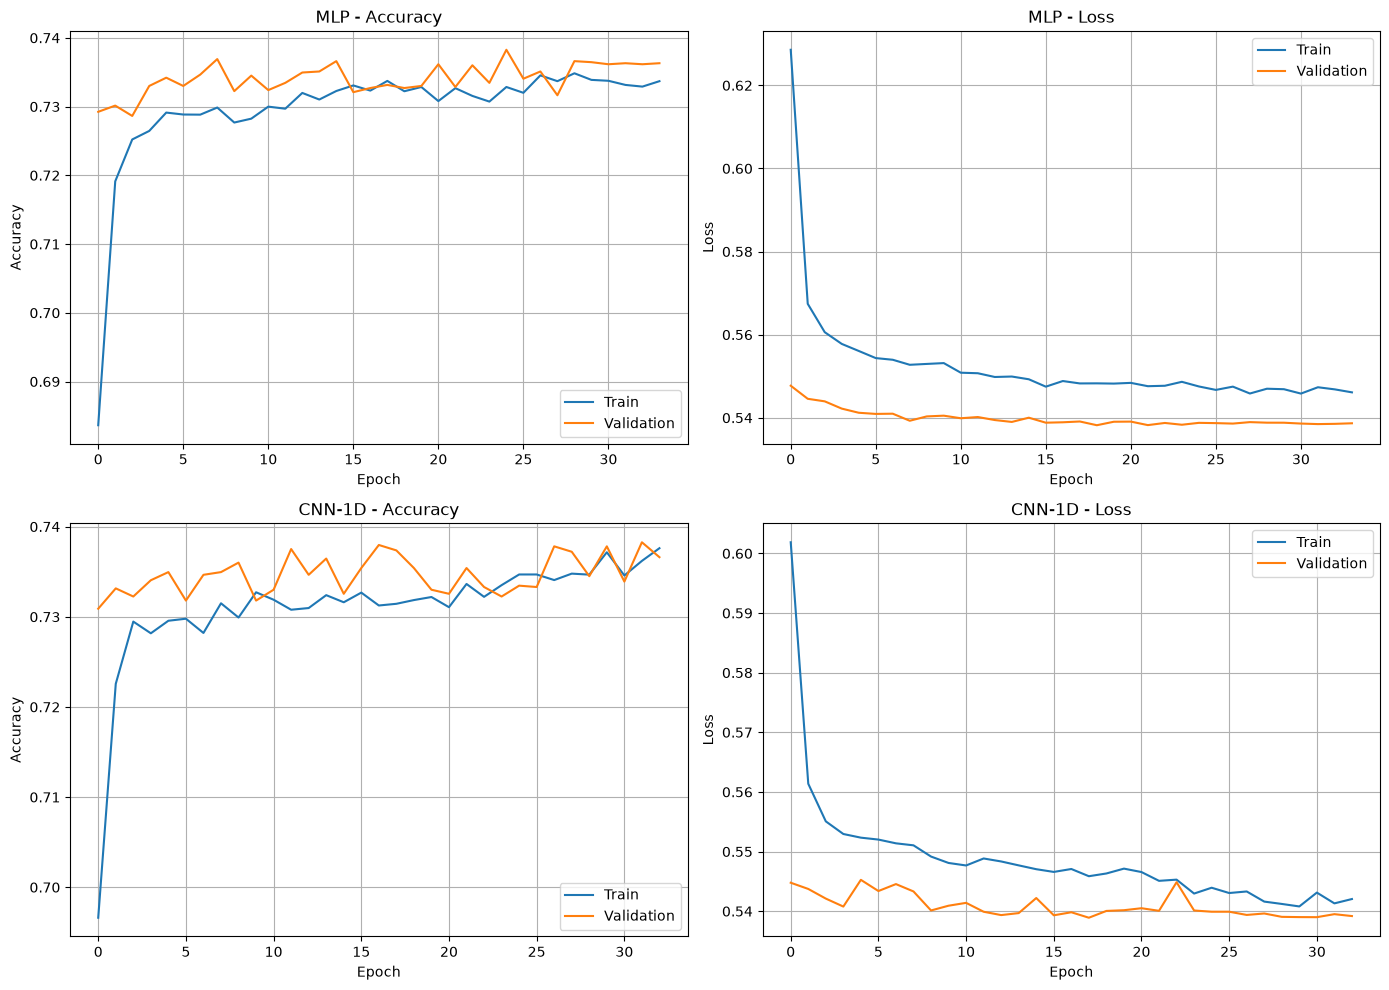

In [34]:
# ============================================
# 6. EVALUASI - Grafik Training
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MLP Accuracy
axes[0, 0].plot(mlp_history.history['accuracy'], label='Train')
axes[0, 0].plot(mlp_history.history['val_accuracy'], label='Validation')
axes[0, 0].set_title('MLP - Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True)

# MLP Loss
axes[0, 1].plot(mlp_history.history['loss'], label='Train')
axes[0, 1].plot(mlp_history.history['val_loss'], label='Validation')
axes[0, 1].set_title('MLP - Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# CNN Accuracy
axes[1, 0].plot(cnn_history.history['accuracy'], label='Train')
axes[1, 0].plot(cnn_history.history['val_accuracy'], label='Validation')
axes[1, 0].set_title('CNN-1D - Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True)

# CNN Loss
axes[1, 1].plot(cnn_history.history['loss'], label='Train')
axes[1, 1].plot(cnn_history.history['val_loss'], label='Validation')
axes[1, 1].set_title('CNN-1D - Loss')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 858us/step
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
📊 HASIL EVALUASI MODEL

🔵 MLP Performance:
  Accuracy  : 0.7301
  Precision : 0.7451
  Recall    : 0.6941
  F1-Score  : 0.7187

🟢 CNN-1D Performance:
  Accuracy  : 0.7309
  Precision : 0.7564
  Recall    : 0.6760
  F1-Score  : 0.7139



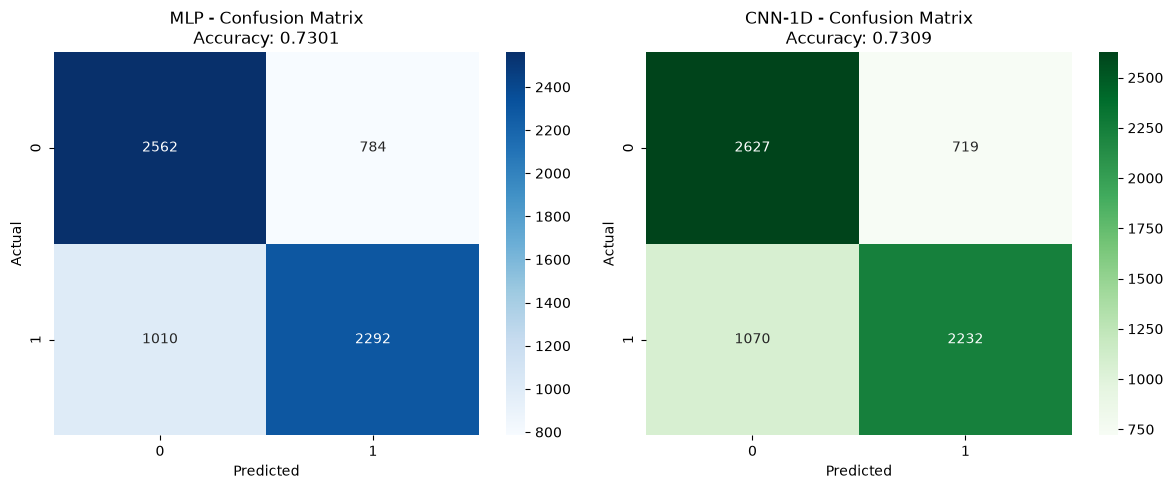

In [35]:
# ============================================
# 6. EVALUASI - Testing
# ============================================

# Prediksi MLP
y_pred_mlp = (mlp_model.predict(X_test) > 0.5).astype(int)

# Prediksi CNN
y_pred_cnn = (cnn_model.predict(X_test_cnn) > 0.5).astype(int)

# Metrik MLP
acc_mlp = accuracy_score(y_test, y_pred_mlp)
prec_mlp = precision_score(y_test, y_pred_mlp)
rec_mlp = recall_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp)

# Metrik CNN
acc_cnn = accuracy_score(y_test, y_pred_cnn)
prec_cnn = precision_score(y_test, y_pred_cnn)
rec_cnn = recall_score(y_test, y_pred_cnn)
f1_cnn = f1_score(y_test, y_pred_cnn)

print("="*60)
print("📊 HASIL EVALUASI MODEL")
print("="*60)

print("\n🔵 MLP Performance:")
print(f"  Accuracy  : {acc_mlp:.4f}")
print(f"  Precision : {prec_mlp:.4f}")
print(f"  Recall    : {rec_mlp:.4f}")
print(f"  F1-Score  : {f1_mlp:.4f}")

print("\n🟢 CNN-1D Performance:")
print(f"  Accuracy  : {acc_cnn:.4f}")
print(f"  Precision : {prec_cnn:.4f}")
print(f"  Recall    : {rec_cnn:.4f}")
print(f"  F1-Score  : {f1_cnn:.4f}")

print("\n" + "="*60)

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MLP
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'MLP - Confusion Matrix\nAccuracy: {acc_mlp:.4f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# CNN
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'CNN-1D - Confusion Matrix\nAccuracy: {acc_cnn:.4f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [37]:
# ============================================
# 7. OUTPUT
# ============================================

if acc_cnn > acc_mlp:
    best_model = cnn_model
    best_name = "CNN-1D"
    best_acc = acc_cnn
else:
    best_model = mlp_model
    best_name = "MLP"
    best_acc = acc_mlp

print(f"Model terbaik: {best_name} dengan akurasi {best_acc:.4f}")

best_model.save('best_model.h5')
print("Model terbaik berhasil disimpan sebagai 'best_model.h5'!")

# Simpan summary - PAKAI ENCODING UTF-8
with open('model_summary.txt', 'w', encoding='utf-8') as f:
    f.write(f"Model terbaik: {best_name}\n")
    f.write(f"Akurasi: {best_acc:.4f}\n")
    f.write("\n" + "="*50 + "\n")
    best_model.summary(print_fn=lambda x: f.write(x + '\n'))

print("Summary model disimpan di 'model_summary.txt'")

Model terbaik: CNN-1D dengan akurasi 0.7309
Model terbaik berhasil disimpan sebagai 'best_model.h5'!


Summary model disimpan di 'model_summary.txt'


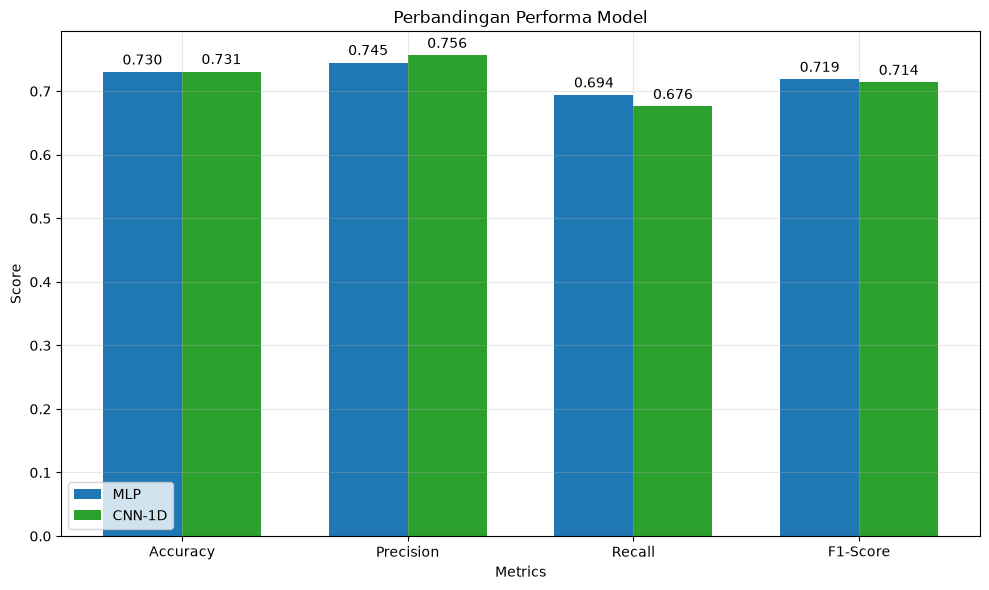

In [38]:
# Grafik perbandingan
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
mlp_scores = [acc_mlp, prec_mlp, rec_mlp, f1_mlp]
cnn_scores = [acc_cnn, prec_cnn, rec_cnn, f1_cnn]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, mlp_scores, width, label='MLP', color='#1f77b4')
bars2 = ax.bar(x + width/2, cnn_scores, width, label='CNN-1D', color='#2ca02c')

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Perbandingan Performa Model')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()